# Example: Let's play around with Classical Hopfield Networks
In this example, we are going to explore encoding and retrieving multiple __binary__ patterns using classical Hopfield Networks. Does the retrieval algorithm presented in lecture __really__ work for multiple memories? (we'll see!)

> __Learning Objectives:__
> 
> By the end of this example, you should be able to:
> * **Encode multiple patterns into a Hopfield network using Hebbian learning**: Apply the Hebbian learning rule to compute network weights from multiple binary patterns and understand how the weights encode pattern information as an outer product sum.
> * **Retrieve corrupted patterns from a Hopfield network**: Implement the asynchronous update algorithm to recover stored patterns from noisy initial states by iteratively minimizing network energy.
> * **Analyze Hopfield network retrieval performance under capacity constraints**: Evaluate how retrieval accuracy changes as the number of encoded patterns approaches the theoretical storage limit and observe the impact of pattern interference on convergence.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Implementations
The notebook uses functions for Hopfield network operations:

> * `decode(s; number_of_rows, number_of_columns)`: Converts a flattened state vector $\mathbf{s}$ back to an $n \times n$ image matrix. This local function (defined below) reshapes the vector, transposes it to match row-major ordering, and replaces $-1$ values with $0$ for grayscale display.

In [2]:
function decode(s::Vector{Int32}; number_of_rows::Int=28, number_of_columns::Int=28)::Array{Int32,2}

    # reconstructed image -
    X = reshape(s, number_of_rows, number_of_columns) |> X -> transpose(X) |> Matrix;
    X̂ = replace(X, -1 => 0);
    
    # return -
    return X̂
end

decode (generic function with 1 method)

### Load the uncorrelated image dataset
In this example, we use a Hopfield network to memorize and retrieve image patterns from [the MNIST handwritten digits dataset](https://en.wikipedia.org/wiki/MNIST_database). We will encode selected digit images into the network weights and then test whether the network can recover each image from a corrupted initial state.

Let's first set some constants that define the problem size and dataset parameters. The comment next to each constant describes its purpose, units, and values:

In [3]:
number_of_training_examples = 30; # how many training examples of *each* number to include from the library
number_digit_array = range(0,length=10,step=1) |> collect; # numbers 0 ... 9
number_of_rows = 28; # number of rows in the image
number_of_cols = 28; # number of cols in the image
number_of_pixels = number_of_rows*number_of_cols; # how many pixels do we have in the image?
number_of_images_to_memorize = 10; # TODO: number of images that we want to encode (change this)

The code block below loads all training images from the dataset directory and stores them in the `training_image_array::Array{Gray{N0f8},3}` variable as a 3D array where images are indexed along the third dimension.

In [4]:
training_image_array =  MyUncorreleatedBlackAndWhiteImageDataset();

In [5]:
training_image_array

[:, :, 1] =
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀


[:, :, 2] =
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀


[:, :, 3] =
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
▀▀▀

Next, we convert the images from matrix format to vector format for network processing.

> * __Why vectorize?__ Each $n\times n$ image array containing grayscale pixel values is flattened into a vector of length $n^2$ by concatenating pixel values in row-major order. This vector representation is required for the Hopfield network, which operates on flattened input patterns.
> * __Floating-point precision:__ Most neural network libraries use `Float32` (single precision) rather than `Float64` (double precision) to reduce memory requirements and improve computational speed. This is especially important for large-scale networks and when using specialized hardware such as [Graphical Processing Units (GPUs)](https://www.nvidia.com/en-us/data-center/h100/).

The vectorized training data will be stored in the `training_image_dataset::Vector{Vector{Float32}}` variable.

In [6]:
training_image_dataset = let

    # initialize
    training_image_dataset = Vector{Vector{Float32}}();
    X = training_image_array; # shorthand
    number_of_rows, number_of_cols = size(X[:,:,1]);
    number_of_pixels = number_of_rows*number_of_cols;

    for t ∈ 1:number_of_training_examples

        Y = X[:,:,t]; # grab the t-th image
        D = reshape(transpose(Y) |> Matrix, number_of_pixels) |> vec |> x -> convert.(Float32,x); # flatten and convert to Float32
        push!(training_image_dataset,D);
    end
    training_image_dataset
end;

In [7]:
training_image_dataset[1]

784-element Vector{Float32}:
 0.0
 0.0
 1.0
 1.0
 0.0
 1.0
 0.0
 1.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 1.0
 1.0
 0.0
 0.0
 0.0
 1.0

___

## Task 1: Learn the Weights of the Network
In this task, we'll learn the weights of the Hopfield network using the training data. A [Hopfield network](https://en.wikipedia.org/wiki/Hopfield_network) uses a special [Hebbian learning rule](https://arxiv.org/pdf/2010.01472), where the weights $w_{ij}\in\mathbf{W}$ are _encoded_ by the image (or memory) the network is trying to learn. How many images can we encode? Let's find out!

> * __How big is $K_{\text{max}}$?__: The maximum theoretical storage limit $K_{\text{max}}$ (the maximum number of possible images that can be stored) of a classical Hopfield network, using the standard Hebbian learning rule, is approximately $K_{max}\sim{0.138}{N}$, where $N$ is the number of neurons (nodes) in the network. Thus, the network can reliably store about 14% of its size in patterns before retrieval errors become significant due to interference between stored patterns.
> * __Reference__ The paper exploring this theoretical limit: [Folli V, Leonetti M, Ruocco G. On the Maximum Storage Capacity of the Hopfield Model. Front Comput Neurosci. 2017 Jan 10;10:144. doi: 10.3389/fncom.2016.00144. PMID: 28119595; PMCID: PMC5222833.](https://pubmed.ncbi.nlm.nih.gov/28119595/)

Let's store the maximum number of images that we can encode in the `Kmax::Int` variable. Let's assume that we have one node for each pixel in the image.

In [8]:
Kmax = 0.138*number_of_pixels |> x-> round(x, RoundDown) # max number of images the network can memorize

108.0

Next, let's generate a random set of image indexes that we encode into the model. We'll store this collection in the `image_index_set_to_encode::Set{Int64}` variable.
> __How do we build this set?__ We specify the number of images that we want in the `number_of_images_to_memorize::Int` variable; then we iterate using [a `while-loop`](https://docs.julialang.org/en/v1/base/base/#while) until we generate the required number of indexes _randomly_. We stop the loop once we hit our target number. Fun data structure question: why do we use [a Julia `Set`](https://docs.julialang.org/en/v1/base/collections/#Base.Set) instead of an array?

The code block below shows how we generate a random set of image indices to encode into the network.

In [9]:
image_index_set_to_encode = let

    # how many images do we want to encode?
    number_of_possible_images = length(training_image_dataset);
    image_index_set_to_encode = Set{Int64}();

    is_ok_to_stop = false; # iteration flag
    while (is_ok_to_stop == false)
        
        # generate a random index -
        j = rand(1:number_of_possible_images);
        push!(image_index_set_to_encode, j); # add to the image set -

        # check: have we hit the number that we want?
        if (length(image_index_set_to_encode) ≥ number_of_images_to_memorize)
            is_ok_to_stop = true;
        end
    end

    # return 
    image_index_set_to_encode;
end;

In [10]:
image_index_set_to_encode

Set{Int64} with 10 elements:
  15
  7
  16
  10
  27
  26
  30
  14
  17
  1

Let's visualize the images we randomly selected to memorize. These will be the "true" images that our network will attempt to recover when given a corrupted noisy version as input.

> __How does the decoding work?__ Each image is stored in the `training_image_dataset::Vector{Vector{Float32}}` as a flattened vector of grayscale pixel values. We convert this vector representation back to the original $n \times n$ binary format for visualization using the `decode(...)` function. The code block below iterates through each selected image index and displays the corresponding binary pattern.

The code block below displays the memorized images that the network will learn to retrieve:

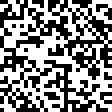

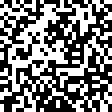

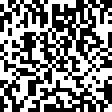

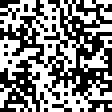

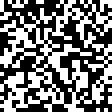

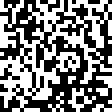

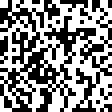

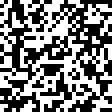

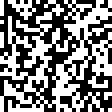

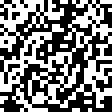

In [11]:
let

    index_vector = image_index_set_to_encode |> collect |> sort; # we'll process this in this order 
    for example_image_index ∈ index_vector
    
        ŝₖ = training_image_dataset[example_image_index]; # raw state *not* scaled to -1,1
        s = Array{Int32,1}(undef, number_of_pixels); # initialize some space
        for i ∈ 1:number_of_pixels
            pixel =  ŝₖ[i] |> x-> round(Int,x); # why do we have to round here?
            if pixel == 0.0
                s[i] = -1
            else
                s[i] = 1;
            end
        end
        display(decode(s) |> img -> Gray.(img))
    end
end

### Encode a Hopfield model
Now that we have the training images let's encode the model. We'll compute the weights and the bias term and store them [in an instance of the `MyClassicalHopfieldNetworkModel` type](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/#VLDataScienceMachineLearningPackage.MyClassicalHopfieldNetworkModel). The weights are stored in the `W` field, and the bias term is stored in the `b` field. 

> __How do we build this model__? We build the model (and estimate the weight matrix and bias vector) using [the `build(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/factory/). This method takes the type of thing we want to construct, namely [a `MyClassicalHopfieldNetworkModel` instance](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/#VLDataScienceMachineLearningPackage.MyClassicalHopfieldNetworkModel), and the memories we want to encode. The (vectorized) memories are stored in the columns of an array. The [`build(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/factory/) returns a model instance with the `W` and `b` fields populated.

Let's store the encoded model in the `model::MyClassicalHopfieldNetworkModel` variable.

In [22]:
model = let

    # initialize -
    number_of_images_to_learn = length(image_index_set_to_encode);
    linearimagecollection = Array{Int32,2}(undef, number_of_pixels, number_of_images_to_learn); # images on columns
    
    # turn our set into a sorted vector -
    index_vector = image_index_set_to_encode |> collect |> sort; # we'll process this in this order 
    for k ∈ eachindex(index_vector)
        
        j = index_vector[k];
        ŝₖ = training_image_dataset[j]; # raw state *not* scaled to -1,1

        # fill the columns of the array -
        for i ∈ 1:number_of_pixels
            pixel =  ŝₖ[i] |> x-> round(Int,x);
            if pixel == 0.0 # hmmm
                linearimagecollection[i,k] = -1;
            else
                linearimagecollection[i,k] = 1;
            end
        end
    end

    # build the model using the encode function -
    model = build(MyClassicalHopfieldNetworkModel, (
        memories = linearimagecollection,
    ));

    # return -
    model
end;

___

## Task 2: Retrieve a memory from the network
In this task, we will retrieve a memory from the Hopfield network starting from a random state vector $\mathbf{s}_{\circ}$. Let's start by specifying which of the images we expect to recover in the `imageindextorecover::Int` variable.

In [23]:
imageindextorecover = 4; # which element of the index vector will we choose?

For comparison purposes later, what is the energy of the true image? Let's look it up from the model's energy dictionary and store it in the `true_image_energy::Float32` variable.

In [24]:
true_image_energy = model.energy[imageindextorecover]

-391.5995f0

Next, we'll build a corrupted initial condition vector $\mathbf{s}_{\circ}$ based on a selected memorized image. This vector will serve as the starting point for the memory recovery algorithm. We initialize the state vector by converting each pixel to the binary scale $\{-1, 1\}$ and then systematically corrupt a fraction of the pixels to simulate noisy input.

> __The $\theta$ corruption parameter:__ The parameter $\theta \in [0,1]$ controls the fraction of pixels we preserve from the original image. Specifically, we keep the first $\theta\cdot{N}$ pixels from the correct image and set the remaining $(1-\theta)\cdot{N}$ pixels to $-1$, simulating damage or noise in the input. For example, if $\theta = 0.5$, we preserve 50% of the original pixel values and corrupt the remaining 50%, creating a noisy version of the true image that the network must restore.


Let's compute the corrupted initial condition vector `sₒ::Array{Int32,1}`.

In [54]:
sₒ = let

    # initialize -
    index_vector = image_index_set_to_encode |> collect |> sort; # we'll process this in this order
    index_of_image_to_encode = index_vector[imageindextorecover]; # -or- choose random
    ŝₖ = training_image_dataset[index_of_image_to_encode]; # raw state *not* scaled to -1,1
    sₒ = Array{Int32,1}(undef, number_of_pixels); # initialize some space
    θ = 0.20; # fraction of pixels that we want to keep correct

    # let's build the corrupted initial condition -
    for i ∈ 1:number_of_pixels
        pixel =  ŝₖ[i] |> x-> round(Int,x); # We have some gray-scale values in the original vector, need to round
        if pixel == 0.0
            sₒ[i] = -1;
        else
            sₒ[i] = 1;
        end
    end

    # # cut 1 - θ fraction of the pixels, replacewith - 1
    number_of_pixels_to_corrupt = round(Int, (1 - θ)*number_of_pixels);
    start =(number_of_pixels - number_of_pixels_to_corrupt) + 1;
    for i ∈ start:number_of_pixels
        sₒ[i] = -1;
    end

    sₒ # return
end;

What does the initial state vector $\mathbf{s}_{\circ}$ look like (this should be a corrupted version of the `imageindextorecover::Int` image):

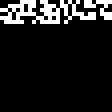

In [55]:
decode(sₒ) |> img -> Gray.(img) # corrupted true image. This is what we give the network

Now that we have a corrupted initial state $\mathbf{s}_{\circ}$, can the network recover the original image?

> __Expected behavior:__ The asynchronous update algorithm iteratively minimizes the network energy by randomly selecting neurons and updating their states based on the activation function. At each step, we record the network state and compute its energy. The algorithm should converge toward the memorized pattern by finding a state that corresponds to a local energy minimum. We expect the energy to generally decrease (or stabilize) as the network evolves from the noisy initial state toward a stored memory pattern.

The recovery algorithm has been implemented in [the `recover(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/). This method accepts:
- `model::MyClassicalHopfieldNetworkModel`: The encoded Hopfield network with learned weights
- `sₒ::Array{Int32,1}`: The corrupted initial state vector
- `true_image_energy::Float32`: The energy of the target memorized pattern (for reference)
- `maxiterations::Int64`: Maximum number of update steps to perform (optional: default is `1000`)
- `patience::Union{Int,Nothing}`: Number of consecutive identical states required to declare convergence (optional: default is `5` or greater)
- `miniterations_before_convergence::Union{Int,Nothing}`: minimum updates to run before checking convergence. If `nothing`, defaults to `patience`.

The method returns:
- `frames::Dict{Int64, Array{Int32,1}}`: A dictionary mapping iteration index to the network state at that iteration
- `energydictionary::Dict{Int64, Float32}`: A dictionary mapping iteration index to the network energy at that iteration

Call [the `recover(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/) below to perform memory retrieval from the corrupted initial state.

In [56]:
frames, energydictionary = recover(model, sₒ, true_image_energy, maxiterations=25*number_of_pixels, 
    patience = 2*number_of_pixels);

┌ Info: Energy value lower than true. Stopping
└ @ VLDataScienceMachineLearningPackage /Users/jeffreyvarner/.julia/packages/VLDataScienceMachineLearningPackage/X4FPP/src/Hopfield.jl:102


Which image does the model recover? The code block below displays the true image (top), the corrupted initial image (middle), and the recovered image (bottom).

> __Check:__ 
> 
> To evaluate the quality of the recovered image, we can compute the Hamming distance between the recovered state and the true image. The Hamming distance quantifies the number of differing pixels, providing a measure of retrieval accuracy. A lower Hamming distance indicates a closer match to the original image. If the Hamming distance is zero, it means the recovered image exactly matches the true image.
> 
> We check if the Hamming distance between the recovered image and the true image is less than the Hamming distance between the corrupted image and the true image. If it is, no error is thrown; otherwise, an error is raised indicating that the recovery was unsuccessful.

So what do we get?

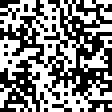

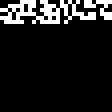

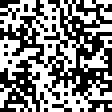

Hamming (best vs true) = 0
Hamming (initial vs true) = 312
Best energy = -391.5995
True energy = -391.5995


In [57]:
let

    # initialize -
    index_vector = image_index_set_to_encode |> collect |> sort; # we'll process this in this order
    my_index_of_image_to_encode = index_vector[imageindextorecover]; # -or- choose random

    # true image -
    ŝₖ = training_image_dataset[my_index_of_image_to_encode]; # raw state *not* scaled to -1,1
    s₁ = Array{Int32,1}(undef, number_of_pixels); # initialize some space
    for i ∈ 1:number_of_pixels
        pixel =  ŝₖ[i] |> x-> round(Int,x); # why do we have to round here?
        if pixel == 0.0
            s₁[i] = -1
        else
            s₁[i] = 1;
        end
    end
    true_image = decode(s₁); # this is the true image
    initial_image = decode(sₒ); # initial corrupted image
    
    # recovered image -
    ks = collect(keys(energydictionary))
    best_key = argmin(k -> energydictionary[k], ks)
    best_state = frames[best_key]
    recovered_image = decode(best_state)

    display(true_image |> img -> Gray.(img))
    display(initial_image |> img -> Gray.(img))
    display(recovered_image |> img -> Gray.(img))

    println("Hamming (best vs true) = ", hamming(best_state, s₁))
    println("Hamming (initial vs true) = ", hamming(sₒ, s₁))
    println("Best energy = ", energydictionary[best_key])
    println("True energy = ", true_image_energy)
end;

Does the energy decrease as we flip the states in the network? Let's plot the values in the `energydictionary::Dict{Int64, Float32}` and see.

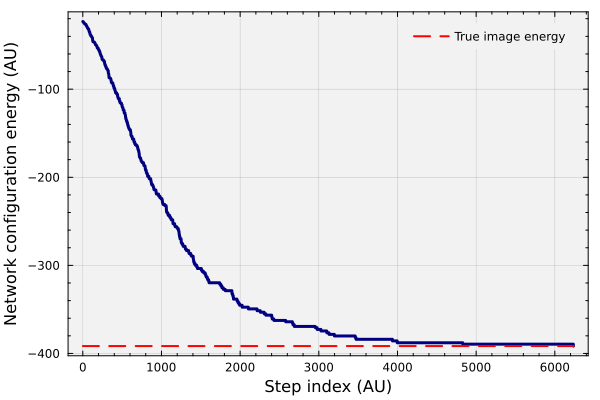

In [58]:
let
    p = plot(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent); 
    plot!(energydictionary, lw=3, c=:navy, label="", xminorticks=true, yminorticks=true);
   
    # plot true energy line -
    TEL = true_image_energy*ones(length(energydictionary));
    plot!(TEL, lw=2, c=:red, label="True image energy", ls=:dash);
    xlabel!("Step index (AU)", fontsize=18)
    ylabel!("Network configuration energy (AU)", fontsize=18)
end

## Summary
This practicum explores encoding and retrieving multiple binary patterns from classical Hopfield networks using Hebbian learning and energy-based optimization.

> __Key Takeaways:__
> 
> * **Hebbian learning for memory storage:** The network weights encode stored patterns through an outer product sum of memories, allowing direct computation of weights without iterative training. This biological learning mechanism enables unsupervised memory formation based on co-activation patterns.
> * **Energy minimization for pattern recovery:** Memory retrieval operates by iteratively updating neuron states to minimize network energy, allowing the algorithm to recover stored patterns from corrupted or noisy initial conditions through local computations.
> * **Storage capacity limits:** Classical Hopfield networks can reliably store approximately 14% of their neuron count in distinct patterns before interference between memories degrades retrieval performance. This fundamental capacity constraint reflects a trade-off between network size and memory density.

Hopfield networks demonstrate how local learning rules and energy functions can implement associative memory, providing a foundation for understanding recurrent neural network dynamics and constrained optimization in neural systems.

___

# Extra
Let's look at a movie showing how the model changes each iteration. Set the `do_I_want_to_see_a_movie = true` to see a frame-by-frame update.

In [59]:
do_I_want_to_see_a_movie = false; # Flag that controls movie play {true | false}. Movie is *slow*

In [60]:
let
    
    if (do_I_want_to_see_a_movie == true)
        number_of_frames_to_view = length(frames);
        for i ∈ 0:(number_of_frames_to_view-1)
            image_index_to_view = i;
            s = frames[image_index_to_view];
            image = decode(s);
            display(Gray.(image))
            println("Turn index = $(i)")
            IJulia.clear_output(true) # may not work in VSCode?
            sleep(0.01) # add some delay
        end
    end
end